## Simulating many particles

This is theory notebook 5/5. No actual new theory is added here, we just look at how to run simulation with a very large number of particles, and how well the simulation performs here. To increase performance, the algorithm is improved.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time

So far, we have only been looking at simulations with 3 or 4 objects. When you want to simulate something like a gas however, you're going to need thousands of particles, so let's see how we can setup a simulation like that.

Of course it is not feasible to specify initial positions and velocities for a large number of particles. We will have to find some clever way to assign them all instead. 
For the positions, it is most straightforward to simple space the particle out randomly throughout the simulated volume. Here the random positions are drawn from a uniform distribution, meaning every spot is equally likely.
For the velocities, we use the thermal or Maxwell-Boltzmann distribution. Here you only need to specify the temperature $T$ of the system, and then you can calculate the distribution of velocities that correspond to this temperature. Per component $i=\{x,y,z\}$ of the velocity, this is given by

\begin{equation}
\nonumber
    f(v_i) = \sqrt{\frac{m}{2\pi k_B T}} \exp{\left(-\frac{mv_i^2}{2k_B T}\right)},
\end{equation}

where $k_B$ is Boltzmann's constant, but we will simply put this value to 1 for simplicity, like we do with Newton's constant. Note that this is really just a Gaussian distribution, with mean $\mu=0$ and standard deviation $\sigma=\sqrt{k_BT/m}$.

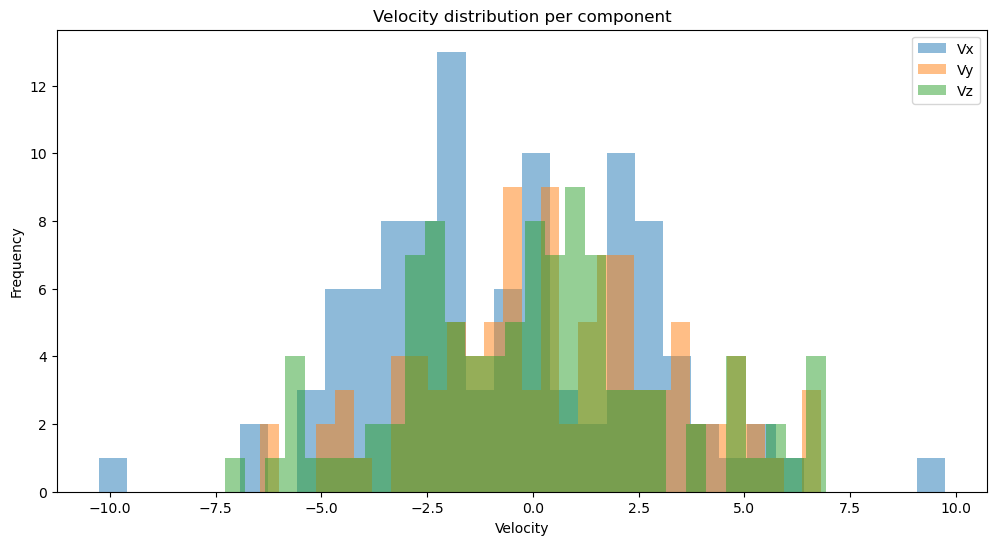

In [8]:
# Set a random seed for reproducibility
np.random.seed(42)

N_steps = 1000
N_objects = 100
masses = np.ones(N_objects)  # all masses are 1

# Space out the particles over a cube of side length 100
positions = np.zeros(shape=[N_steps, N_objects, 3])
positions[0] = np.random.uniform(-50, 50, (N_objects, 3))

# Get each velocity components from the thermal distribution
temp = 10
k_B = 1  # Boltzmann constant
velocities = np.zeros(shape=[N_steps, N_objects, 3])
velocities[0] = np.random.normal(loc=0, scale=np.sqrt(k_B * temp / masses[0]), size=(N_objects, 3))

# Plot velocity distribution
plt.figure(figsize=(12, 6))
plt.hist(velocities[0][:,0], bins=30, alpha=0.5, label='Vx')
plt.hist(velocities[0][:,1], bins=30, alpha=0.5, label='Vy')
plt.hist(velocities[0][:,2], bins=30, alpha=0.5, label='Vz')
plt.title('Velocity distribution per component')
plt.xlabel('Velocity')
plt.ylabel('Frequency')
plt.legend()
plt.show()

These look like reasonable distributions. As a second check, we can look if the resulting speeds are as expected given the thermal energy of $\frac{3}{2} k_B T$. Here we should have 

\begin{equation}
\nonumber
    \frac{1}{2} m \langle v^2 \rangle = \frac{3}{2} k_B T,
\end{equation}

where $\langle v^2 \rangle$ is the average of the squared speed.

In [9]:
speeds = np.linalg.norm(velocities[0], axis=1)
quotient_factor = 3*k_B*temp / (masses[0]*np.mean(speeds**2))
print(f"Quotient of thermal and kinetic energy: {quotient_factor:.4f}")

Quotient of thermal and kinetic energy: 1.0231


That's pretty much the same, as it should be. Now we can run the simulation. We'll use periodic boundary conditions, so that we can simulate a volume of gas within a larger volume.

In [10]:
# Other constants
G = 1
dt = 1e-3  # timestep
e = 1.0  # coefficient of restitution
box_length = 100
periodic = True
e_wall = None
times = np.arange(N_steps) * dt

radii = np.ones(N_objects) * 0.1  # all radii are 0.1

use_external_force = False
def external_force():
    # placeholder
    return None

In [5]:
def gravity_force(m_i, m_j, r_i, r_j):
    """
    Calculate the gravitational force exerted on object i by object j.
    Parameters:
        - m_i (float): Mass of object i
        - m_j (float): Mass of object j
        - r_i (np.array): Position vector of object i
        - r_j (np.array): Position vector of object j
    """
    r_ij = r_i - r_j
    distance = np.linalg.norm(r_ij)
    unit_r_ij = r_ij / distance
    return -G * m_i * m_j / distance**2 * unit_r_ij

def next_velocity(current_velocity, next_acceleration, current_acceleration):
    """
    Find the velocity at the next timestep using the Verlet integration method.
    Parameters:
        - current_velocity (np.array): Velocity at the current timestep
        - next_acceleration (np.array): Acceleration at the next timestep
        - current_acceleration (np.array): Acceleration at the current timestep
    """
    return current_velocity + 0.5 * dt * (next_acceleration + current_acceleration)

def next_position(current_position, current_velocity, current_acceleration):
    """
    Find the position at the next timestep using the velocity Verlet integration method.
    Parameters:
        - current_position (np.array): Position at the current timestep
        - current_velocity (np.array): Velocity at the current timestep
        - current_acceleration (np.array): Acceleration at the current timestep
    """
    return current_position + current_velocity * dt + 0.5 * current_acceleration * dt**2

def galilean_transform(target_velocity, frame_velocity):
    """
    Perform a Galilean transformation.
    Parameters:
        - target_velocity (np.array): Velocity of the object that is to be transformed
        - frame_velocity (np.array): Velocity of the frame you want to transform to
    """
    return target_velocity - frame_velocity

def get_rotation_angles(position_i, position_j):
    """
    Calculate the rotation angles around the axes to align with 
    the line between the centres of the objects i and j.
    Parameters:
        - position_i (np.array): Position vector of object i
        - position_j (np.array): Position vector of object j
    Returns:
        - alpha (float): Angle around the x axis
        - beta (float): Angle around the y axis
        - gamma (float): Angle around the z axis
    """
    difference = position_i - position_j  # (delta_x, delta_y, delta_z)
    # Using arctan2 ensures the right quadrant sign
    alpha = np.arctan2(difference[2], difference[1])
    beta = np.arctan2(difference[0], difference[2])
    gamma = np.arctan2(difference[1], difference[0])
    return alpha, beta, gamma

def rotation(alpha, beta, gamma, target_vector):
    """
    Perform a rotation around the x, y and z axis.
    Parameters:
        - alpha (float): Angle around the x axis
        - beta (float): Angle around the y axis
        - gamma (float): Angle around the z axis
        - target_vector (np.array): Vector you want to rotate
    """
    rotation_matrix_x = np.array([
        [1, 0, 0],
        [0, np.cos(alpha), -np.sin(alpha)],
        [0, np.sin(alpha), np.cos(alpha)]
    ])
    rotation_matrix_y = np.array([
        [np.cos(beta), 0, np.sin(beta)],
        [0, 1, 0],
        [-np.sin(beta), 0, np.cos(beta)]
    ])
    rotation_matrix_z = np.array([
        [np.cos(gamma), -np.sin(gamma), 0],
        [np.sin(gamma), np.cos(gamma), 0],
        [0, 0, 1]
    ])
    combined_rotation = rotation_matrix_x @ rotation_matrix_y @ rotation_matrix_z  # Note xyz
    return combined_rotation @ target_vector

def inverse_rotation(alpha, beta, gamma, target_vector):
    """
    Perform an inverse rotation around the x, y and z axis,
    compared to the function above. Note no minus sign on the
    angles is needed relative to above!
    Parameters:
        - alpha (float): Angle around the x axis
        - beta (float): Angle around the y axis
        - gamma (float): Angle around the z axis
        - target_vector (np.array): Vector you want to rotate
    """
    rotation_matrix_x = np.array([
        [1, 0, 0],
        [0, np.cos(alpha), -np.sin(-alpha)],
        [0, np.sin(-alpha), np.cos(alpha)]
    ])
    rotation_matrix_y = np.array([
        [np.cos(beta), 0, np.sin(-beta)],
        [0, 1, 0],
        [-np.sin(-beta), 0, np.cos(beta)]
    ])
    rotation_matrix_z = np.array([
        [np.cos(gamma), -np.sin(-gamma), 0],
        [np.sin(-gamma), np.cos(gamma), 0],
        [0, 0, 1]
    ])
    combined_rotation = rotation_matrix_z @ rotation_matrix_y @ rotation_matrix_x  # Note zyx
    return combined_rotation @ target_vector

def velocity_transfer_collision(m_i, m_j, velocity_before_i):
    """
    Calculate the velocity of object i and j after an (in)elastic
    collision, where i moves and j is stationary.
    Parameters:
        - m_i (float): Mass of object i
        - m_j (float): Mass of object j
        - velocity_before_i (np.array): Velocity of object i before the collision
    Returns:
        - velocity_after_i (np.array): Velocity of object i after the collision
        - velocity_after_j (np.array): Velocity of object j after the collision
    """
    velocity_after_i = (m_i - e * m_j) / (m_i + m_j) * velocity_before_i
    velocity_after_j = (1 + e) * m_i / (m_i + m_j) * velocity_before_i
    return velocity_after_i, velocity_after_j

def objects_move_towards_each_other(position_i, position_j, velocity_i, velocity_j):
    """
    Determine if objects i and j are moving towards each other, so that a collision 
    can happen. This is the case if for any of the components of the position and 
    velocity vectors, the position component of i is smaller and the velocity 
    component of i is larger, or vice versa.
    Parameters:
        - position_i (np.array): Position vector of object i
        - position_j (np.array): Position vector of object j
        - velocity_i (np.array): Velocity vector of object i
        - velocity_j (np.array): Velocity vector of object j
    Returns:
        - bool: True if objects move towards each other
    """
    position_mask = position_i > position_j
    velocity_mask = velocity_i > velocity_j
    # We need position_i to be smaller and velocity_i larger or vice versa,
    # meaning these masks do not have the same value
    collisions = position_mask != velocity_mask
    # If any of these is True, there will be a collision
    return np.any(collisions)

def velocity_transfer_collision_wall(velocity_before_i):
    """
    Calculate the velocity of object i after an (in)elastic
    collision with the wall.
    Parameters:
        - velocity_before_i (np.array): Velocity of object i before the collision
    Returns:
        - velocity_after_i (np.array): Velocity of object i after the collision
    """
    velocity_after_i = -e_wall * velocity_before_i
    return velocity_after_i

def wall_collision_check_and_transfer(position_i, velocity_i):
    """
    Check if the object is colliding for each axis/component,
    and apply the velocity transfer if so.
    Parameters:
        - position_i (np.array): Position vector of object i
        - velocity_i (np.array): Velocity vector of object i
    Returns:
        - velocity_after_i (np.array): Velocity vector of object i after wall collision
    """
    walls = 0.5*np.array([box_length]*3)
    # Find where the object is outside the box
    where_cross = np.logical_or(position_i > walls, position_i < -walls)

    # Determine if a collision can happen, if the object moves towards the wall
    collisions = (position_i > 0) == (velocity_i > 0)

    # Apply velocity transfer where both conditions are met per component
    velocity_after_i = np.where(
        np.logical_and(where_cross, collisions),
        velocity_transfer_collision_wall(velocity_i),
        velocity_i
    )
    return velocity_after_i

def closest_copy_coordinates(position_i, positions):
    """
    Find the coordinates of the closest copy of each object relative to
    the object i according to the minimal image convention.
    Parameters:
        - position_i (np.array): Position vector of object i
        - positions (np.array): Array of position vectors of all objects
    Returns:
        - copy_positions (np.array): Array of position vectors of the closest copies of all objects
    """
    copy_positions = position_i -  (position_i - positions + 0.5*box_length) % box_length + 0.5*box_length
    return copy_positions

def apply_periodic_crossing(position_i):
    """
    Check if an object has crossed the periodic boundary, 
    and apply the correction in position if so.
    Parameters:
        - position_i (np.array): Position vector of object i
    Returns:
        - crossed_positions (np.array): Position vector of object i after applying periodic crossing correction
    """
    crossed_positions = np.copy(position_i)
    where_cross_positive = position_i > 0.5*box_length
    where_cross_negative = position_i < -0.5*box_length
    crossed_positions[where_cross_positive] -= box_length
    crossed_positions[where_cross_negative] += box_length
    return crossed_positions

Simulation took 119.51 seconds.


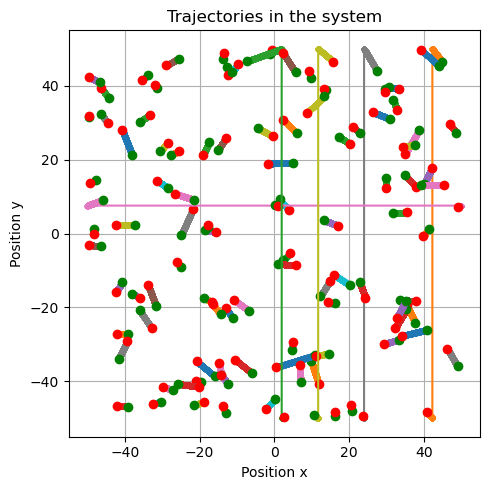

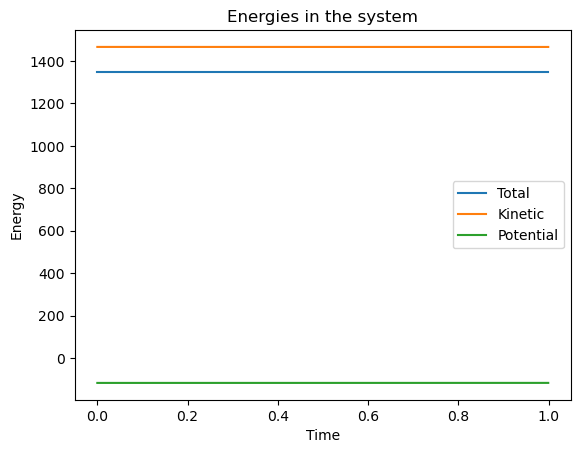

In [11]:
start_time = time.time()

# Also need to keep the previous acceleration for velocity
# Note we don't save these for all timesteps, only the previous one
previous_accelerations = np.zeros(shape=[N_objects, 3])

# Then also determine acceleration for step 0
for j in range(N_objects):
    force = np.zeros(3)  # to add up all forces on object j

    if periodic:  # get closest copy positions for object j
        copy_positions = closest_copy_coordinates(positions[0][j], positions[0])

    for k in range(N_objects):
        # Consider all other objects k, so without k==j
        if k != j:
            # Check for periodic box
            if not periodic:
                force += gravity_force(masses[j], masses[k], positions[0][j], positions[0][k])
            else:  # Apply minimal image convention
                force += gravity_force(masses[j], masses[k], positions[0][j], copy_positions[k])
    
    # Calculate the external force
    if use_external_force:
        force += external_force()
    
    previous_accelerations[j] = force / masses[j]  # update these to contain step 0 accelerations

# Main simulation loop
for i in range(1, N_steps):  # 0 set by initial conditions
    for j in range(N_objects):
        # Update positions, with the already calculated previous acceleration
        positions[i][j] = next_position(positions[i-1][j], velocities[i-1][j], previous_accelerations[j])
    
    # Once all positions are updated, calculate new accelerations and update velocities
    for j in range(N_objects):
        force = np.zeros(3)  # to add up all forces on object j

        if periodic:  # get closest copy positions for object j
            copy_positions = closest_copy_coordinates(positions[i][j], positions[i])

        for k in range(N_objects):
            # Consider all other objects k, so without k==j
            if k != j:
                # Check for periodic box
                if not periodic:
                    force += gravity_force(masses[j], masses[k], positions[i][j], positions[i][k])
                else:  # Apply minimal image convention
                    force += gravity_force(masses[j], masses[k], positions[i][j], copy_positions[k])
        
        # Calculate the external force
        if use_external_force:
            force += external_force()
        
        acceleration = force / masses[j]

        # So update velocities
        velocities[i][j] = next_velocity(velocities[i-1][j], acceleration, previous_accelerations[j])
        # And update the previous acceleration for the next loop
        previous_accelerations[j] = acceleration
    
    # Collisions
    for j in range(N_objects):
        position_j = positions[i][j]
        velocity_j = velocities[i][j]
        # Now only check for collisions between object pairs
        for k in range(j+1, N_objects):
            position_k = positions[i][k]
            velocity_k = velocities[i][k]
            # Check collision condition
            difference = position_j - position_k
            distance = np.linalg.norm(difference)
            if distance <= (radii[j] + radii[k]) and objects_move_towards_each_other(position_j, position_k, velocity_j, velocity_k):
                # 1 Galilean transform, with velocity_k as the frame velocity
                transformed_velocity = galilean_transform(velocity_j, velocity_k)

                # 2 Rotation
                alpha, beta, gamma = get_rotation_angles(position_j, position_k)
                rotated_transformed_velocity = rotation(alpha, beta, gamma, transformed_velocity)

                # 3 Velocity transfer
                velocity_after_j, velocity_after_k = velocity_transfer_collision(masses[j], masses[k], rotated_transformed_velocity)

                # 4 Inverse rotation
                velocity_after_j = inverse_rotation(alpha, beta, gamma, velocity_after_j)
                velocity_after_k = inverse_rotation(alpha, beta, gamma, velocity_after_k)

                # 5 Inverse Galilean transform
                velocity_after_j = galilean_transform(velocity_after_j, -velocity_k)
                velocity_after_k = galilean_transform(velocity_after_k, -velocity_k)

                # And finally assign
                velocities[i][j] = velocity_after_j
                velocities[i][k] = velocity_after_k
    
    # Boundary conditions
    if box_length is None:
        continue  # no boundary conditions, so skip to next timestep

    for j in range(N_objects):
        # Check if the object is outside the box
        if np.any(np.abs(positions[i][j]) > 0.5*box_length):
            # Check finite or periodic box
            if not periodic:
                velocities[i][j] = wall_collision_check_and_transfer(positions[i][j], velocities[i][j])
            else:
                positions[i][j] = apply_periodic_crossing(positions[i][j])

# Calculate energies
kinetic_per_particle = 0.5 * masses * np.sum(velocities**2, axis=2)
kinetic_total = np.sum(kinetic_per_particle, axis=1)

potential_total = np.zeros(shape=[N_steps])
for j in range(N_objects-1):  # don't need to consider the last object, is cancelled in next loop
    r_j = positions[:,j,:]
    for k in range(j+1, N_objects):  # start from the object after j
        if not periodic:
            r_k = positions[:,k,:]
            distance = np.linalg.norm(r_j - r_k, axis=1)  # distance between j and k at all timesteps
        else:  # Apply minimal image convention
            copy_r_k = closest_copy_coordinates(r_j, positions[:,k,:])
            distance = np.linalg.norm(r_j - copy_r_k, axis=1)
        potential_jk = -G * masses[j] * masses[k] / distance
        potential_total += potential_jk

energy = kinetic_total + potential_total

end_time = time.time()
print(f"Simulation took {end_time - start_time:.2f} seconds.")

# Plot of trajectories in xy-plane
plt.figure(figsize=(5,5))
for i in range(N_objects):
    obj_i_positions = positions[:,i,:]
    plt.plot(obj_i_positions[:,0], obj_i_positions[:,1], marker='.', label=f'Object {i+1}')
    # Object starts at green dot, ends at red dot
    plt.plot(obj_i_positions[0,0], obj_i_positions[0,1], marker='.', color='green', markersize=12)
    plt.plot(obj_i_positions[-1,0], obj_i_positions[-1,1], marker='.', color='red', markersize=12)

plt.xlabel('Position x')
plt.ylabel('Position y')
plt.title('Trajectories in the system')
#plt.legend()
plt.grid()
#plt.xlim(-10.2, 10.2)
#plt.ylim(-10.2, 10.2)
plt.tight_layout()
plt.show()

# Plot the different energies over time
plt.figure()
plt.plot(times, energy, label="Total")
plt.plot(times, kinetic_total, label="Kinetic")
plt.plot(times, potential_total, label="Potential")
plt.title("Energies in the system")
plt.xlabel("Time")
plt.ylabel("Energy")
plt.legend()
plt.show()

This looks like a good start to a simulation, with randomly placed particles moving in all directions. It is however quite slow, taking about 2 minutes for 1000 steps with only 100 objects; running this simulation with thousands of particles isn't going to be fun.

We can however speed up the algorithm a bit still, by making use of the fact that interaction occur between particles and that the force of particle $i$ on $j$ is minus the force of particle $j$ on $i$. By defining a 'forces' array at each timestep, we thus only need to calculate half as many force vectors, as we can then assign the other half as minus that calculated force on the corresponding particle.

Simulation took 79.62 seconds.


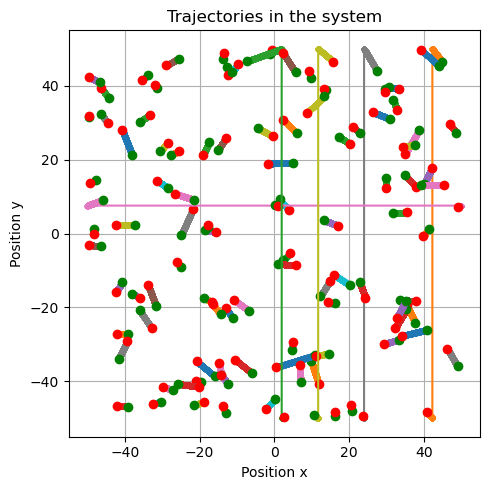

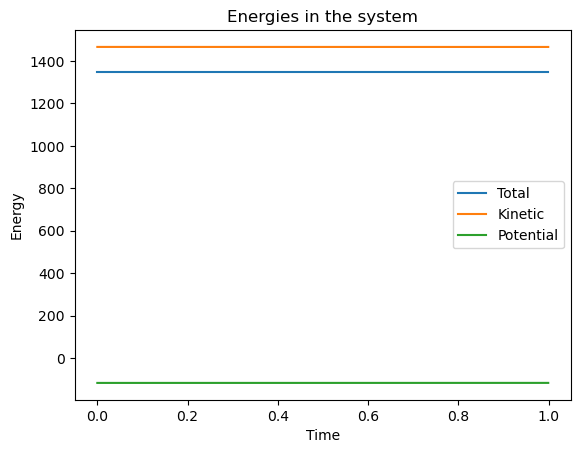

In [12]:
start_time = time.time()

# Also need to keep the previous acceleration for velocity
# Note we don't save these for all timesteps, only the previous one
forces = np.zeros(shape=[N_objects, 3])  # to add up all forces on each object
for j in range(N_objects):
    if periodic:  # get closest copy positions for object j
        copy_positions = closest_copy_coordinates(positions[0][j], positions[0])

    for k in range(j+1, N_objects):
        # Consider remaining objects k, so k>j
        # Check for periodic box
        if not periodic:
            force = gravity_force(masses[j], masses[k], positions[0][j], positions[0][k])
            forces[j] += force
            forces[k] -= force
        else:  # Apply minimal image convention
            force = gravity_force(masses[j], masses[k], positions[0][j], copy_positions[k])
            forces[j] += force
            forces[k] -= force
    
    # Calculate the external force
    if use_external_force:
        forces[j] += external_force()
    
previous_accelerations = forces / masses.reshape(-1,1)  # update these to contain step 0 accelerations

# Main simulation loop
for i in range(1, N_steps):  # 0 set by initial conditions
    # Update positions, with the already calculated previous acceleration
    positions[i] = next_position(positions[i-1], velocities[i-1], previous_accelerations)
    
    # Once all positions are updated, calculate new accelerations and update velocities
    forces = np.zeros(shape=[N_objects, 3])  # to add up all forces on each object
    for j in range(N_objects):
        if periodic:  # get closest copy positions for object j
            copy_positions = closest_copy_coordinates(positions[i][j], positions[i])

        for k in range(j+1, N_objects):
            # Consider remaining objects k, so k>j
            # Check for periodic box
            if not periodic:
                force = gravity_force(masses[j], masses[k], positions[i][j], positions[i][k])
                forces[j] += force
                forces[k] -= force
            else:  # Apply minimal image convention
                force = gravity_force(masses[j], masses[k], positions[i][j], copy_positions[k])
                forces[j] += force
                forces[k] -= force
        
        # Calculate the external force
        if use_external_force:
            forces[j] += external_force()
        
    accelerations = forces / masses.reshape(-1,1)

    # So update velocities
    velocities[i] = next_velocity(velocities[i-1], accelerations, previous_accelerations)
    # And update the previous acceleration for the next loop
    previous_accelerations = accelerations
    
    # Collisions
    for j in range(N_objects):
        position_j = positions[i][j]
        velocity_j = velocities[i][j]
        # Now only check for collisions between object pairs
        for k in range(j+1, N_objects):
            position_k = positions[i][k]
            velocity_k = velocities[i][k]
            # Check collision condition
            difference = position_j - position_k
            distance = np.linalg.norm(difference)
            if distance <= (radii[j] + radii[k]) and objects_move_towards_each_other(position_j, position_k, velocity_j, velocity_k):
                # 1 Galilean transform, with velocity_k as the frame velocity
                transformed_velocity = galilean_transform(velocity_j, velocity_k)

                # 2 Rotation
                alpha, beta, gamma = get_rotation_angles(position_j, position_k)
                rotated_transformed_velocity = rotation(alpha, beta, gamma, transformed_velocity)

                # 3 Velocity transfer
                velocity_after_j, velocity_after_k = velocity_transfer_collision(masses[j], masses[k], rotated_transformed_velocity)

                # 4 Inverse rotation
                velocity_after_j = inverse_rotation(alpha, beta, gamma, velocity_after_j)
                velocity_after_k = inverse_rotation(alpha, beta, gamma, velocity_after_k)

                # 5 Inverse Galilean transform
                velocity_after_j = galilean_transform(velocity_after_j, -velocity_k)
                velocity_after_k = galilean_transform(velocity_after_k, -velocity_k)

                # And finally assign
                velocities[i][j] = velocity_after_j
                velocities[i][k] = velocity_after_k
    
    # Boundary conditions
    if box_length is None:
        continue  # no boundary conditions, so skip to next timestep

    for j in range(N_objects):
        # Check if the object is outside the box
        if np.any(np.abs(positions[i][j]) > 0.5*box_length):
            # Check finite or periodic box
            if not periodic:
                velocities[i][j] = wall_collision_check_and_transfer(positions[i][j], velocities[i][j])
            else:
                positions[i][j] = apply_periodic_crossing(positions[i][j])

# Calculate energies
kinetic_per_particle = 0.5 * masses * np.sum(velocities**2, axis=2)
kinetic_total = np.sum(kinetic_per_particle, axis=1)

potential_total = np.zeros(shape=[N_steps])
for j in range(N_objects-1):  # don't need to consider the last object, is cancelled in next loop
    r_j = positions[:,j,:]
    for k in range(j+1, N_objects):  # start from the object after j
        if not periodic:
            r_k = positions[:,k,:]
            distance = np.linalg.norm(r_j - r_k, axis=1)  # distance between j and k at all timesteps
        else:  # Apply minimal image convention
            copy_r_k = closest_copy_coordinates(r_j, positions[:,k,:])
            distance = np.linalg.norm(r_j - copy_r_k, axis=1)
        potential_jk = -G * masses[j] * masses[k] / distance
        potential_total += potential_jk

energy = kinetic_total + potential_total

end_time = time.time()
print(f"Simulation took {end_time - start_time:.2f} seconds.")

# Plot of trajectories in xy-plane
plt.figure(figsize=(5,5))
for i in range(N_objects):
    obj_i_positions = positions[:,i,:]
    plt.plot(obj_i_positions[:,0], obj_i_positions[:,1], marker='.', label=f'Object {i+1}')
    # Object starts at green dot, ends at red dot
    plt.plot(obj_i_positions[0,0], obj_i_positions[0,1], marker='.', color='green', markersize=12)
    plt.plot(obj_i_positions[-1,0], obj_i_positions[-1,1], marker='.', color='red', markersize=12)

plt.xlabel('Position x')
plt.ylabel('Position y')
plt.title('Trajectories in the system')
#plt.legend()
plt.grid()
#plt.xlim(-10.2, 10.2)
#plt.ylim(-10.2, 10.2)
plt.tight_layout()
plt.show()

# Plot the different energies over time
plt.figure()
plt.plot(times, energy, label="Total")
plt.plot(times, kinetic_total, label="Kinetic")
plt.plot(times, potential_total, label="Potential")
plt.title("Energies in the system")
plt.xlabel("Time")
plt.ylabel("Energy")
plt.legend()
plt.show()

The result with this improved algorithm is exactly the same, as it should be. It also allowed to do some calculations outside of loops (and I also just missed some things) which speeds things up even more. As a result, the simulation took only about 80 seconds now, so it is about 1.5 times faster.

Let's then also run with some more particles and for more timesteps, although this will still take some time to run.

In [15]:
np.random.seed(42)

N_steps = 1000
N_objects = 200
masses = np.ones(N_objects)  # all masses are 1

# Space out the particles over a cube of side length 100
positions = np.zeros(shape=[N_steps, N_objects, 3])
positions[0] = np.random.uniform(-50, 50, (N_objects, 3))

# Get each velocity components from the thermal distribution
temp = 10
k_B = 1  # Boltzmann constant
velocities = np.zeros(shape=[N_steps, N_objects, 3])
velocities[0] = np.random.normal(loc=0, scale=np.sqrt(k_B * temp / masses[0]), size=(N_objects, 3))

G = 1
dt = 1e-3  # timestep
e = 1.0  # coefficient of restitution
box_length = 100
periodic = True
e_wall = None
times = np.arange(N_steps) * dt

radii = np.ones(N_objects) * 0.1  # all radii are 0.1

use_external_force = False
def external_force():
    # placeholder
    return None

Simulation took 325.92 seconds.


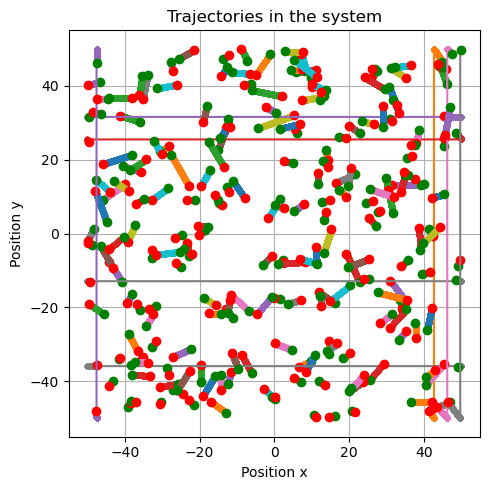

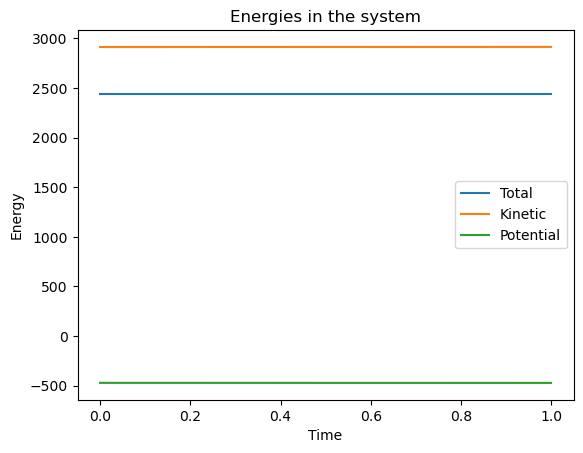

In [16]:
start_time = time.time()

# Also need to keep the previous acceleration for velocity
# Note we don't save these for all timesteps, only the previous one
forces = np.zeros(shape=[N_objects, 3])  # to add up all forces on each object
for j in range(N_objects):
    if periodic:  # get closest copy positions for object j
        copy_positions = closest_copy_coordinates(positions[0][j], positions[0])

    for k in range(j+1, N_objects):
        # Consider remaining objects k, so k>j
        # Check for periodic box
        if not periodic:
            force = gravity_force(masses[j], masses[k], positions[0][j], positions[0][k])
            forces[j] += force
            forces[k] -= force
        else:  # Apply minimal image convention
            force = gravity_force(masses[j], masses[k], positions[0][j], copy_positions[k])
            forces[j] += force
            forces[k] -= force
    
    # Calculate the external force
    if use_external_force:
        forces[j] += external_force()
    
previous_accelerations = forces / masses.reshape(-1,1)  # update these to contain step 0 accelerations

# Main simulation loop
for i in range(1, N_steps):  # 0 set by initial conditions
    # Update positions, with the already calculated previous acceleration
    positions[i] = next_position(positions[i-1], velocities[i-1], previous_accelerations)
    
    # Once all positions are updated, calculate new accelerations and update velocities
    forces = np.zeros(shape=[N_objects, 3])  # to add up all forces on each object
    for j in range(N_objects):
        if periodic:  # get closest copy positions for object j
            copy_positions = closest_copy_coordinates(positions[i][j], positions[i])

        for k in range(j+1, N_objects):
            # Consider remaining objects k, so k>j
            # Check for periodic box
            if not periodic:
                force = gravity_force(masses[j], masses[k], positions[i][j], positions[i][k])
                forces[j] += force
                forces[k] -= force
            else:  # Apply minimal image convention
                force = gravity_force(masses[j], masses[k], positions[i][j], copy_positions[k])
                forces[j] += force
                forces[k] -= force
        
        # Calculate the external force
        if use_external_force:
            forces[j] += external_force()
        
    accelerations = forces / masses.reshape(-1,1)

    # So update velocities
    velocities[i] = next_velocity(velocities[i-1], accelerations, previous_accelerations)
    # And update the previous acceleration for the next loop
    previous_accelerations = accelerations
    
    # Collisions
    for j in range(N_objects):
        position_j = positions[i][j]
        velocity_j = velocities[i][j]
        # Now only check for collisions between object pairs
        for k in range(j+1, N_objects):
            position_k = positions[i][k]
            velocity_k = velocities[i][k]
            # Check collision condition
            difference = position_j - position_k
            distance = np.linalg.norm(difference)
            if distance <= (radii[j] + radii[k]) and objects_move_towards_each_other(position_j, position_k, velocity_j, velocity_k):
                # 1 Galilean transform, with velocity_k as the frame velocity
                transformed_velocity = galilean_transform(velocity_j, velocity_k)

                # 2 Rotation
                alpha, beta, gamma = get_rotation_angles(position_j, position_k)
                rotated_transformed_velocity = rotation(alpha, beta, gamma, transformed_velocity)

                # 3 Velocity transfer
                velocity_after_j, velocity_after_k = velocity_transfer_collision(masses[j], masses[k], rotated_transformed_velocity)

                # 4 Inverse rotation
                velocity_after_j = inverse_rotation(alpha, beta, gamma, velocity_after_j)
                velocity_after_k = inverse_rotation(alpha, beta, gamma, velocity_after_k)

                # 5 Inverse Galilean transform
                velocity_after_j = galilean_transform(velocity_after_j, -velocity_k)
                velocity_after_k = galilean_transform(velocity_after_k, -velocity_k)

                # And finally assign
                velocities[i][j] = velocity_after_j
                velocities[i][k] = velocity_after_k
    
    # Boundary conditions
    if box_length is None:
        continue  # no boundary conditions, so skip to next timestep

    for j in range(N_objects):
        # Check if the object is outside the box
        if np.any(np.abs(positions[i][j]) > 0.5*box_length):
            # Check finite or periodic box
            if not periodic:
                velocities[i][j] = wall_collision_check_and_transfer(positions[i][j], velocities[i][j])
            else:
                positions[i][j] = apply_periodic_crossing(positions[i][j])

# Calculate energies
kinetic_per_particle = 0.5 * masses * np.sum(velocities**2, axis=2)
kinetic_total = np.sum(kinetic_per_particle, axis=1)

potential_total = np.zeros(shape=[N_steps])
for j in range(N_objects-1):  # don't need to consider the last object, is cancelled in next loop
    r_j = positions[:,j,:]
    for k in range(j+1, N_objects):  # start from the object after j
        if not periodic:
            r_k = positions[:,k,:]
            distance = np.linalg.norm(r_j - r_k, axis=1)  # distance between j and k at all timesteps
        else:  # Apply minimal image convention
            copy_r_k = closest_copy_coordinates(r_j, positions[:,k,:])
            distance = np.linalg.norm(r_j - copy_r_k, axis=1)
        potential_jk = -G * masses[j] * masses[k] / distance
        potential_total += potential_jk

energy = kinetic_total + potential_total

end_time = time.time()
print(f"Simulation took {end_time - start_time:.2f} seconds.")

# Plot of trajectories in xy-plane
plt.figure(figsize=(5,5))
for i in range(N_objects):
    obj_i_positions = positions[:,i,:]
    plt.plot(obj_i_positions[:,0], obj_i_positions[:,1], marker='.', label=f'Object {i+1}')
    # Object starts at green dot, ends at red dot
    plt.plot(obj_i_positions[0,0], obj_i_positions[0,1], marker='.', color='green', markersize=12)
    plt.plot(obj_i_positions[-1,0], obj_i_positions[-1,1], marker='.', color='red', markersize=12)

plt.xlabel('Position x')
plt.ylabel('Position y')
plt.title('Trajectories in the system')
#plt.legend()
plt.grid()
#plt.xlim(-10.2, 10.2)
#plt.ylim(-10.2, 10.2)
plt.tight_layout()
plt.show()

# Plot the different energies over time
plt.figure()
plt.plot(times, energy, label="Total")
plt.plot(times, kinetic_total, label="Kinetic")
plt.plot(times, potential_total, label="Potential")
plt.title("Energies in the system")
plt.xlabel("Time")
plt.ylabel("Energy")
plt.legend()
plt.show()

Twice as many particles results in about 4 times the runtime still; three times as many particles in 8.4 times the runtime. So it grows almost quadratically still. Running with thousands of particles this still is not reasonable with this algorithm. 

One thing we can do, as a bit of a workaround, is to decrease the simulated volume. Because of our periodic boundary conditions, this still acts as if embedded in a larger volume, but this will increase the density so that more interactions can occur and the simulation is a bit more interesting. (Of course, at some point you would simulate too small a volume to still be able to say that it is representative of a much larger one, but let's assume that is not yet the case below.)

In [17]:
np.random.seed(42)

N_steps = 1000
N_objects = 100
masses = np.ones(N_objects)  # all masses are 1

# Space out the particles over a cube of side length 10
positions = np.zeros(shape=[N_steps, N_objects, 3])
positions[0] = np.random.uniform(-5, 5, (N_objects, 3))

# Get each velocity components from the thermal distribution
temp = 10
k_B = 1  # Boltzmann constant
velocities = np.zeros(shape=[N_steps, N_objects, 3])
velocities[0] = np.random.normal(loc=0, scale=np.sqrt(k_B * temp / masses[0]), size=(N_objects, 3))

G = 1
dt = 5e-3  # timestep
e = 1.0  # coefficient of restitution
box_length = 10
periodic = True
e_wall = None
times = np.arange(N_steps) * dt

radii = np.ones(N_objects) * 0.1  # all radii are 0.1

use_external_force = False
def external_force():
    # placeholder
    return None

Simulation took 79.89 seconds.


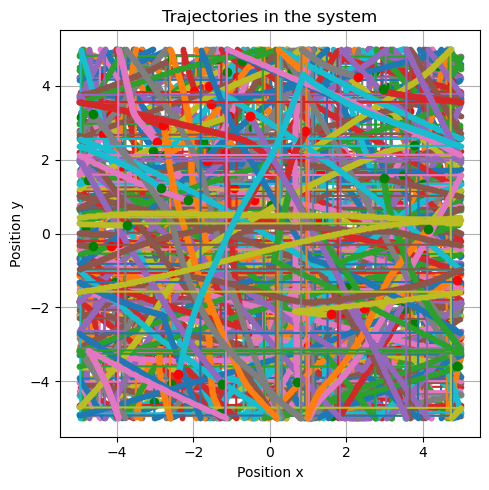

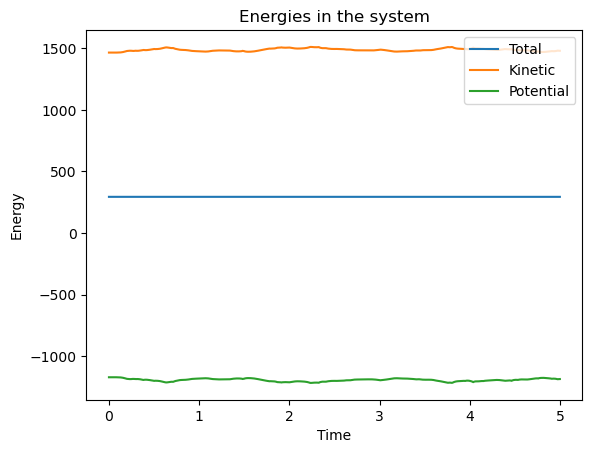

In [18]:
start_time = time.time()

# Also need to keep the previous acceleration for velocity
# Note we don't save these for all timesteps, only the previous one
forces = np.zeros(shape=[N_objects, 3])  # to add up all forces on each object
for j in range(N_objects):
    if periodic:  # get closest copy positions for object j
        copy_positions = closest_copy_coordinates(positions[0][j], positions[0])

    for k in range(j+1, N_objects):
        # Consider remaining objects k, so k>j
        # Check for periodic box
        if not periodic:
            force = gravity_force(masses[j], masses[k], positions[0][j], positions[0][k])
            forces[j] += force
            forces[k] -= force
        else:  # Apply minimal image convention
            force = gravity_force(masses[j], masses[k], positions[0][j], copy_positions[k])
            forces[j] += force
            forces[k] -= force
    
    # Calculate the external force
    if use_external_force:
        forces[j] += external_force()
    
previous_accelerations = forces / masses.reshape(-1,1)  # update these to contain step 0 accelerations

# Main simulation loop
for i in range(1, N_steps):  # 0 set by initial conditions
    # Update positions, with the already calculated previous acceleration
    positions[i] = next_position(positions[i-1], velocities[i-1], previous_accelerations)
    
    # Once all positions are updated, calculate new accelerations and update velocities
    forces = np.zeros(shape=[N_objects, 3])  # to add up all forces on each object
    for j in range(N_objects):
        if periodic:  # get closest copy positions for object j
            copy_positions = closest_copy_coordinates(positions[i][j], positions[i])

        for k in range(j+1, N_objects):
            # Consider remaining objects k, so k>j
            # Check for periodic box
            if not periodic:
                force = gravity_force(masses[j], masses[k], positions[i][j], positions[i][k])
                forces[j] += force
                forces[k] -= force
            else:  # Apply minimal image convention
                force = gravity_force(masses[j], masses[k], positions[i][j], copy_positions[k])
                forces[j] += force
                forces[k] -= force
        
        # Calculate the external force
        if use_external_force:
            forces[j] += external_force()
        
    accelerations = forces / masses.reshape(-1,1)

    # So update velocities
    velocities[i] = next_velocity(velocities[i-1], accelerations, previous_accelerations)
    # And update the previous acceleration for the next loop
    previous_accelerations = accelerations
    
    # Collisions
    for j in range(N_objects):
        position_j = positions[i][j]
        velocity_j = velocities[i][j]
        # Now only check for collisions between object pairs
        for k in range(j+1, N_objects):
            position_k = positions[i][k]
            velocity_k = velocities[i][k]
            # Check collision condition
            difference = position_j - position_k
            distance = np.linalg.norm(difference)
            if distance <= (radii[j] + radii[k]) and objects_move_towards_each_other(position_j, position_k, velocity_j, velocity_k):
                # 1 Galilean transform, with velocity_k as the frame velocity
                transformed_velocity = galilean_transform(velocity_j, velocity_k)

                # 2 Rotation
                alpha, beta, gamma = get_rotation_angles(position_j, position_k)
                rotated_transformed_velocity = rotation(alpha, beta, gamma, transformed_velocity)

                # 3 Velocity transfer
                velocity_after_j, velocity_after_k = velocity_transfer_collision(masses[j], masses[k], rotated_transformed_velocity)

                # 4 Inverse rotation
                velocity_after_j = inverse_rotation(alpha, beta, gamma, velocity_after_j)
                velocity_after_k = inverse_rotation(alpha, beta, gamma, velocity_after_k)

                # 5 Inverse Galilean transform
                velocity_after_j = galilean_transform(velocity_after_j, -velocity_k)
                velocity_after_k = galilean_transform(velocity_after_k, -velocity_k)

                # And finally assign
                velocities[i][j] = velocity_after_j
                velocities[i][k] = velocity_after_k
    
    # Boundary conditions
    if box_length is None:
        continue  # no boundary conditions, so skip to next timestep

    for j in range(N_objects):
        # Check if the object is outside the box
        if np.any(np.abs(positions[i][j]) > 0.5*box_length):
            # Check finite or periodic box
            if not periodic:
                velocities[i][j] = wall_collision_check_and_transfer(positions[i][j], velocities[i][j])
            else:
                positions[i][j] = apply_periodic_crossing(positions[i][j])

# Calculate energies
kinetic_per_particle = 0.5 * masses * np.sum(velocities**2, axis=2)
kinetic_total = np.sum(kinetic_per_particle, axis=1)

potential_total = np.zeros(shape=[N_steps])
for j in range(N_objects-1):  # don't need to consider the last object, is cancelled in next loop
    r_j = positions[:,j,:]
    for k in range(j+1, N_objects):  # start from the object after j
        if not periodic:
            r_k = positions[:,k,:]
            distance = np.linalg.norm(r_j - r_k, axis=1)  # distance between j and k at all timesteps
        else:  # Apply minimal image convention
            copy_r_k = closest_copy_coordinates(r_j, positions[:,k,:])
            distance = np.linalg.norm(r_j - copy_r_k, axis=1)
        potential_jk = -G * masses[j] * masses[k] / distance
        potential_total += potential_jk

energy = kinetic_total + potential_total

end_time = time.time()
print(f"Simulation took {end_time - start_time:.2f} seconds.")

# Plot of trajectories in xy-plane
plt.figure(figsize=(5,5))
for i in range(N_objects):
    obj_i_positions = positions[:,i,:]
    plt.plot(obj_i_positions[:,0], obj_i_positions[:,1], marker='.', label=f'Object {i+1}')
    # Object starts at green dot, ends at red dot
    plt.plot(obj_i_positions[0,0], obj_i_positions[0,1], marker='.', color='green', markersize=12)
    plt.plot(obj_i_positions[-1,0], obj_i_positions[-1,1], marker='.', color='red', markersize=12)

plt.xlabel('Position x')
plt.ylabel('Position y')
plt.title('Trajectories in the system')
#plt.legend()
plt.grid()
#plt.xlim(-10.2, 10.2)
#plt.ylim(-10.2, 10.2)
plt.tight_layout()
plt.show()

# Plot the different energies over time
plt.figure()
plt.plot(times, energy, label="Total")
plt.plot(times, kinetic_total, label="Kinetic")
plt.plot(times, potential_total, label="Potential")
plt.title("Energies in the system")
plt.xlabel("Time")
plt.ylabel("Energy")
plt.legend()
plt.show()

The trajectories are a bit of a mess at this point, which is to be expected for a larger density. But the constant energy means that things still should be going well. (I have also seen simulations with slight changes in total energy, which could be fixed with a smaller timestep. But since we don't want to increase the number of steps further, and it does not break the simulation, these aren't problematic.) Let's look at the trajectories of only a couple particles for more insight.

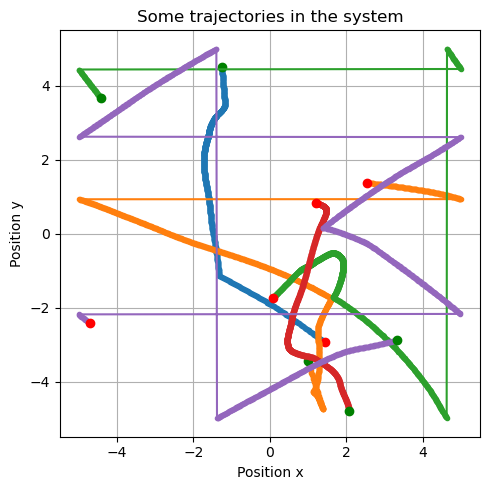

In [19]:
# Plot of trajectories in xy-plane
plt.figure(figsize=(5,5))
for i in range(5):
    obj_i_positions = positions[:,i,:]
    plt.plot(obj_i_positions[:,0], obj_i_positions[:,1], marker='.', label=f'Object {i+1}')
    # Object starts at green dot, ends at red dot
    plt.plot(obj_i_positions[0,0], obj_i_positions[0,1], marker='.', color='green', markersize=12)
    plt.plot(obj_i_positions[-1,0], obj_i_positions[-1,1], marker='.', color='red', markersize=12)

plt.xlabel('Position x')
plt.ylabel('Position y')
plt.title('Some trajectories in the system')
#plt.legend()
plt.grid()
#plt.xlim(-10.2, 10.2)
#plt.ylim(-10.2, 10.2)
plt.tight_layout()
plt.show()

That looks pretty reasonable, with some clear collisions happening throughout the simulation.

Let's then also look at the temperature evolution during the simulation. Like before, this can calculated using the average speed in the simulation. Note the temperature does not start exactly at 10 due to the random initial velocities, but is close to it.

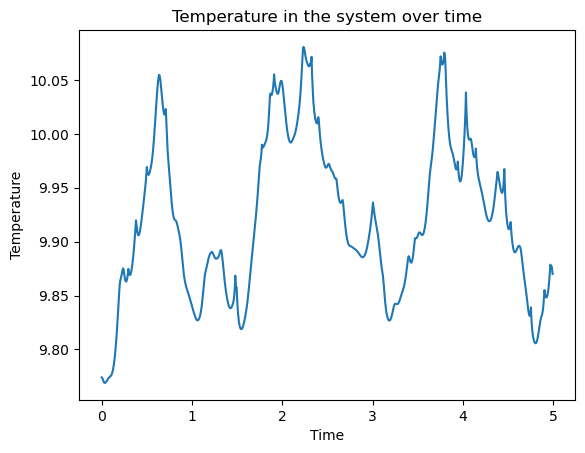

In [20]:
speeds_per_particle = np.linalg.norm(velocities, axis=2)
sim_temp = masses[0] * np.mean(speeds_per_particle**2, axis=1) / (3*k_B)
plt.plot(times, sim_temp)
plt.xlabel("Time")
plt.ylabel("Temperature")
plt.title("Temperature in the system over time")
plt.show()

The temperature varies slightly, but this mostly seems like random variation and not some trend. Given that gravity pulls the gas together in some of the (randomly placed) higher density regions, but the collisions make particles move apart again, I also wouldn't really expect to see a change in temperature.

As a final note, there do exist other simulation algorithms that are more well-suited for these kind of large simulations. Here you don't simulate individual particles as that is simply too computationally expensive. Examples are particle mesh methods, where a sort of grid is laid out that replaces individual particles, and smoothed-particle hydrodynamics, where many particles are replaced by single 'smoothed out' objects.

As for the C++ implementation: its runtime is about 63 seconds instead of 80 seconds, so a fair bit faster, but also not so much that we can run with far more particles using that code. Do note that the results from the C++ simulation will not look exactly the same as from the Python simulation because of the random initial conditions, which cannot be matched exactly. (A further technical note on all this, is that you do need to compile the code using the -03 flag for optimization; the standard -00 used for debugging when compiling in VS Code, like I was doing before, is actually far slower than Python.)